<a href="https://colab.research.google.com/github/alfavinyl/streaming_analisis_de_datos/blob/main/Streaming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import pandas as pd
import kagglehub
import os

#IMPORTACION NETFLIX
path = kagglehub.dataset_download("shivamb/netflix-shows")

full_path = os.path.join(path, "netflix_titles.csv")
print("Path to dataset files:", path)

archivos = os.listdir(path)
print("Archivos en la carpeta:", archivos)

df_netflix = pd.read_csv(full_path)

#IMPORTACION PRIME VIDEO
path = kagglehub.dataset_download("shivamb/amazon-prime-movies-and-tv-shows")

archivos = os.listdir(path)
print("Archivos en la carpeta:", archivos)

full_path = os.path.join(path, "amazon_prime_titles.csv")
print("Path to dataset files:", path)

df_prime = pd.read_csv(full_path)

#IMPORTACION DISNEY+
path = kagglehub.dataset_download("shivamb/disney-movies-and-tv-shows")

archivos = os.listdir(path)
print("Archivos en la carpeta:", archivos)

full_path = os.path.join(path, "disney_plus_titles.csv")
print("Path to dataset files:", path)

df_disney = pd.read_csv(full_path)

#UNION DE COLUMNAS
# Agrega columna identificadora ANTES de unir
df_netflix['platform'] = 'Netflix'
df_prime['platform']   = 'Prime Video'
df_disney['platform']  = 'Disney+'

# Revisa que las columnas sean iguales en los 3
print(df_netflix.columns.tolist())
print(df_prime.columns.tolist())
print(df_disney.columns.tolist())

# Normalizar nombres de columnas
for df in [df_netflix, df_prime, df_disney]:
    df.columns = df.columns.str.lower().str.replace(' ', '_')

# Unir los 3 datasets
df_universal = pd.concat([df_netflix, df_prime, df_disney], ignore_index=True)

print(f"Total de registros: {len(df_universal)}")
print(f"\nRegistros por plataforma:")
print(df_universal['platform'].value_counts())

# ── Valores nulos ──
print("Nulos por columna:")
print(df_universal.isnull().sum())

# ── Limpiar date_added (quitar espacios en blanco) ──
df_universal['date_added'] = df_universal['date_added'].str.strip()

# ── Convertir date_added a datetime ──
df_universal['date_added'] = pd.to_datetime(df_universal['date_added'], errors='coerce')

# ── Extraer año y mes en que fue agregado a la plataforma ──
df_universal['year_added'] = df_universal['date_added'].dt.year
df_universal['month_added'] = df_universal['date_added'].dt.month

# ── Separar duración en número y unidad ──
# "90 min" → 90 | "2 Seasons" → 2
df_universal['duration_value'] = df_universal['duration'].str.extract(r'(\d+)').astype(float)
df_universal['duration_unit']  = df_universal['duration'].str.extract(r'([a-zA-Z]+)')

# ── Resumen final ──
#.shape nos devuelve una tupla de (filas, columnas)
print(f'Filas: {df_universal.shape[0]} | Columnas: {df_universal.shape[1]}')
print(f"\nShape final: {df_universal.shape}")
print(df_universal.dtypes)


Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows
Archivos en la carpeta: ['netflix_titles.csv']


100%|██████████| 1.61M/1.61M [00:00<00:00, 66.9MB/s]

Extracting files...
Archivos en la carpeta: ['amazon_prime_titles.csv']
Path to dataset files: /root/.cache/kagglehub/datasets/shivamb/amazon-prime-movies-and-tv-shows/versions/1


100%|██████████| 131k/131k [00:00<00:00, 45.1MB/s]

Extracting files...
Archivos en la carpeta: ['disney_plus_titles.csv']
Path to dataset files: /root/.cache/kagglehub/datasets/shivamb/disney-movies-and-tv-shows/versions/2
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'platform']
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'platform']
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'platform']
Total de registros: 19925

Registros por plataforma:
platform
Prime Video    9668
Netflix        8807
Disney+        1450
Name: count, dtype: int64
Nulos por columna:
show_id             0
type                0
title               0
director         5190
cast             2248
country         10046
date_added       9526
release_year        0
rating            344
duratio

Filas: 19925 | Columnas: 17

Shape final: (19925, 17)
show_id                   object
type                      object
title                     object
director                  object
cast                      object
country                   object
date_added        datetime64[ns]
release_year               int64
rating                    object
duration                  object
listed_in                 object
description               object
platform                  object
year_added               float64
month_added              float64
duration_value           float64
duration_unit             object
dtype: object


# FASE 1 — Exploración inicial del dataset unido

In [ ]:
#P1. ¿Cuántos registros tiene cada plataforma en df_universal?
registrosporplataforma = df_universal.groupby('platform').size()
print(registrosporplataforma)
#df.groupby('columna_a_agrupar')['columna_a_analizar'].funcion()

platform
Disney+        1450
Netflix        8807
Prime Video    9668
dtype: int64


In [ ]:
#P2. ¿Cuántos títulos únicos hay en total? ¿Y por plataforma?
df_universal['title'].nunique()

df_universal.groupby('platform')['title'].nunique()


,title
platform,
Disney+,1450
Netflix,8807
Prime Video,9668


In [ ]:
#P3. ¿Qué porcentaje del catálogo de cada plataforma son películas vs series?

variable = df_universal.groupby('platform')['type'].value_counts(normalize=True)
resultado =variable * 100
print(resultado.round(2))


platform     type   
Disney+      Movie      72.55
             TV Show    27.45
Netflix      Movie      69.62
             TV Show    30.38
Prime Video  Movie      80.82
             TV Show    19.18
Name: proportion, dtype: float64


In [ ]:
#P4. ¿Cuál es el rango de años de lanzamiento (release_year) por plataforma?
df_universal.groupby('platform').agg({'release_year':['min', 'max']})




release_year      
                     min   max
platform                      
Disney+             1928  2021
Netflix             1925  2021
Prime Video         1920  2021

# Fase 2 — Análisis de contenido

In [ ]:
#P5. ¿Cuál plataforma tiene el contenido más reciente en promedio?
df_universal.groupby('platform')['release_year'].median()

,release_year
platform,
Disney+,2011.0
Netflix,2017.0
Prime Video,2016.0


In [ ]:
#P6. ¿Cuáles son los top 10 géneros más frecuentes en todo el catálogo combinado?
listed_in_partes = df_universal['listed_in'].str.split(',')
lista_de_generos = listed_in_partes.explode()
lista_de_generos_sin_espacios = lista_de_generos.str.strip()
lista_conteo_generos = lista_de_generos_sin_espacios.value_counts()
lista_top10_generos = lista_conteo_generos.head(10)
print(lista_top10_generos)

listed_in
Drama                     3821
International Movies      2752
Comedy                    2625
Dramas                    2427
Comedies                  1674
Action                    1657
Suspense                  1501
International TV Shows    1351
Kids                      1226
Documentary               1167
Name: count, dtype: int64


In [ ]:
#P7. ¿Qué géneros domina cada plataforma?
# Guardar las dos columnas en un nuevo DataFrame
df_seleccion = df_universal[['listed_in', 'platform']]
# Aplicar split solo a 'listed_in'
df_seleccion['listed_in'] = df_seleccion['listed_in'].str.split(',')
df_seleccion_ordenado = df_seleccion.explode('listed_in')
df_seleccion_ordenado['listed_in'] = df_seleccion_ordenado['listed_in'].str.strip()

#print(df_seleccion_ordenado)
#Agrupación -- #df.groupby('columna_a_agrupar')['columna_a_analizar'].funcion()
resultado = df_seleccion_ordenado.groupby('platform')['listed_in'].value_counts()
resultado.groupby('platform').head(5)



/tmp/ipykernel_4783/2987944622.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_seleccion['listed_in'] = df_seleccion['listed_in'].str.split(',')


platform     listed_in             
Disney+      Family                     632
             Animation                  542
             Comedy                     526
             Action-Adventure           452
             Animals & Nature           208
Netflix      International Movies      2752
             Dramas                    2427
             Comedies                  1674
             International TV Shows    1351
             Documentaries              869
Prime Video  Drama                     3687
             Comedy                    2099
             Action                    1657
             Suspense                  1501
             Kids                      1085
Name: count, dtype: int64

In [ ]:
#P8. ¿Cuál es la duración promedio de películas por plataforma?
df_universalmovie = df_universal[df_universal['type'] == 'Movie']
#Agrupación -- #df.groupby('columna_a_agrupar')['columna_a_analizar'].funcion()
df_universalmovie.groupby('platform')['duration_value'].mean().round(2)

,duration_value
platform,
Disney+,71.91
Netflix,99.58
Prime Video,91.31


# Fase 3 — Análisis de países y directores

In [ ]:
#P9. ¿Cuáles son los top 5 países productores de contenido por plataforma?

#Guardar las dos columnas en un nuevo DataFrame
df_pais = df_universal[['country', 'platform']]
df_pais = df_pais.dropna()
# Aplicar split solo a 'country'
df_pais['country'] = df_pais['country'].str.split(',')
df_pais_ordenado = df_pais.explode('country')
df_pais_ordenado['country'] = df_pais_ordenado['country'].str.strip()

resultado_pais = df_pais_ordenado.groupby('platform')['country'].value_counts()
resultado_pais.groupby('platform').head(5)


platform     country       
Disney+      United States     1184
             United Kingdom     101
             Canada              77
             Australia           23
             France              22
Netflix      United States     3690
             India             1046
             United Kingdom     806
             Canada             445
             France             393
Prime Video  United States      334
             India              246
             United Kingdom      67
             Canada              35
             France              20
Name: count, dtype: int64

In [ ]:
#P10. ¿Cuáles son los directores con más títulos en cada plataforma?
#Guardar las dos columnas en un nuevo DataFrame
df_director = df_universal[['director', 'platform']]
df_director = df_director.dropna()
# Aplicar split solo a 'director'
df_director['director'] = df_director['director'].str.split(',')
df_director_ordenado = df_director.explode('director')
df_director_ordenado['director'] = df_director_ordenado['director'].str.strip()

resultado_director = df_director_ordenado.groupby('platform')['director'].value_counts()
resultado_director.groupby('platform').head(5)

platform     director             
Disney+      Jack Hannah               17
             John Lasseter             16
             Paul Hoen                 16
             Wilfred Jackson           16
             Clyde Geronimi            13
Netflix      Rajiv Chilaka             22
             Jan Suter                 21
             Raúl Campos               19
             Marcus Raboy              16
             Suhas Kadav               16
Prime Video  Mark Knight              114
             Cannis Holder             62
             Moonbug Entertainment     37
             Jay Chapman               34
             Arthur van Merwijk        30
Name: count, dtype: int64

In [ ]:
#P11. ¿Qué decisión tomamos con los 10,046 nulos en country?
"""
Este no es un ejercicio de código sino de criterio analítico.
Ya tomaste la decisión de eliminarlos para el ejercicio 9, pero ahora piensa en el impacto real:

df_universal tiene 19,925 registros
country tiene 10,046 nulos — eso es aproximadamente el 50% del dataset

Pregunta: Si eliminas el 50% de los datos cada vez que analizas por país, ¿tus conclusiones sobre países son completamente confiables? ¿Cómo comunicarías esa limitación en tu notebook?

Respuesta: Son confiables en sentido que no inventamos nada, pero son parciales porque no sabemos exactamente qué porcentaje se quitó de cada plataforma y no sabemos a quien le podria pertenecer esa serie o pelicula, creo que la forma de comnicarlo es diciendo que el resultado es una muestra parcial debido a la falta de datos.
"""
df_paisnulos = df_universal[['country', 'platform']]
nulos = df_universal['country'].isnull()
#print(nulos)
#df.groupby('columna_a_agrupar')['columna_a_analizar'].funcion()
#df_paisnulos.groupby('platform')['country'].isnull()
registrosnulos = df_paisnulos['country'].isnull().groupby(df_paisnulos['platform']).sum()
registrosporplataforma = df_universal.groupby('platform').size()


resultado = registrosnulos * 100 / registrosporplataforma
print(resultado.round(2))

"""
Prime Video tiene un 93% de nulos en country — eso significa que prácticamente todo su análisis de países era con solo el 7% de su catálogo.
Eso cambia completamente la interpretación del ejercicio 9. Ahora tu conclusión en el notebook debería decir algo como:
"El análisis de países debe interpretarse con cautela. Prime Video tiene un 93% de valores nulos en country, por lo que sus resultados representan apenas el 7% de su catálogo real. Netflix y Disney+ son más confiables con 9% y 15% de nulos respectivamente."
"""

platform
Disney+        15.10
Netflix         9.44
Prime Video    93.05
dtype: float64


# Fase 4 — Agrupaciones y comparativas

In [ ]:
#P12. ¿Cómo ha crecido el catálogo de cada plataforma año con año?
#PORCENTAJE DE NULOS EN YEAR ADDED
#nuevo dataset con dos columnas
df_agregados = df_universal[['year_added', 'platform']]
#df.groupby('columna_a_agrupar')['columna_a_analizar'].funcion()

#Verificamos los valores nulos de year added y los agrupamos por plataformas
registrosnulos = df_agregados['year_added'].isnull().groupby(df_agregados['platform']).sum()
#registros totales
registrosporplataforma = df_universal.groupby('platform').size()
#porcentajes
resultado = registrosnulos * 100 / registrosporplataforma
#print(resultado.round(2))

df_net_dis = df_universal[df_universal['platform'] != 'Prime Video']


df_net_dis.groupby(['platform','year_added']).size()

plataformaporaño =




platform  year_added
Disney+   2019.0         765
          2020.0         352
          2021.0         330
Netflix   2008.0           2
          2009.0           2
          2010.0           1
          2011.0          13
          2012.0           3
          2013.0          11
          2014.0          24
          2015.0          82
          2016.0         429
          2017.0        1188
          2018.0        1649
          2019.0        2016
          2020.0        1879
          2021.0        1498
dtype: int64

In [ ]:
#P13. ¿En qué meses del año cada plataforma agrega más contenido?
#La pregunta es si hay patrones estacionales — por ejemplo, ¿agregan más contenido en diciembre por las fiestas?

#PORCENTAJE DE NULOS EN YEAR ADDED
#nuevo dataset con dos columnas
df_agregados_mes = df_universal[['month_added', 'platform']]
#df.groupby('columna_a_agrupar')['columna_a_analizar'].funcion()

#Verificamos los valores nulos de year added y los agrupamos por plataformas
registrosnulos_mes = df_agregados_mes['month_added'].isnull().groupby(df_agregados_mes['platform']).sum()
# Crear diccionario de mapeo
meses_dict = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}


#registros totales
registrosporplataforma = df_universal.groupby('platform').size()
#porcentajes
resultado = registrosnulos_mes * 100 / registrosporplataforma
#print(resultado.round(2))

df_net_dis = df_universal[df_universal['platform'] != 'Prime Video'].copy()

df_net_dis['mes_nombre'] = df_net_dis['month_added'].map(meses_dict)

df_net_dis.groupby(['platform','mes_nombre']).size()



platform  mes_nombre
Disney+   Abril          86
          Agosto         50
          Diciembre      52
          Enero          61
          Febrero        44
          Julio          85
          Junio          52
          Marzo          24
          Mayo           62
          Noviembre     809
          Octubre        63
          Septiembre     59
Netflix   Abril         764
          Agosto        755
          Diciembre     813
          Enero         738
          Febrero       563
          Julio         827
          Junio         728
          Marzo         742
          Mayo          632
          Noviembre     705
          Octubre       760
          Septiembre    770
dtype: int64

In [ ]:
#P14. Tabla comparativa por plataforma
#TOTAL DE TITULOS
total_titulos = df_universal.groupby('platform')['title'].nunique()
#PRCENTAJE DE PELICULAS
df_plataformas = df_universal.groupby('platform')['type'].value_counts(normalize=True)
peliculas = df_plataformas.loc[:, 'Movie']
resultado_peliculas = peliculas * 100
porcentaje_peliculas = resultado_peliculas.round(2)

#PRCENTAJE DE SERIES
df_plataformas = df_universal.groupby('platform')['type'].value_counts(normalize=True)

series = df_plataformas.loc[:, 'TV Show']
resultado_series = series * 100
porcentaje_series = resultado_series.round(2)
#AÑO PROMEDIO
promedio_año = df_universal.groupby('platform')['release_year'].median()
#DURACION PROMEDIO
df_universalmovie = df_universal[df_universal['type'] == 'Movie']
#Agrupación -- #df.groupby('columna_a_agrupar')['columna_a_analizar'].funcion()
duracion_promedio = df_universalmovie.groupby('platform')['duration_value'].mean().round(2)

#ARMADO DEL NUEVO DATAFRAME
pd.DataFrame({
    'total_titulos': total_titulos,
    'pct_peliculas': porcentaje_peliculas,
    'pct_series': porcentaje_series,
    'año_promedio': promedio_año,
    'duracion_promedio': duracion_promedio
})


,total_titulos,pct_peliculas,pct_series,año_promedio,duracion_promedio
platform,,,,,
Disney+,1450,72.55,27.45,2011.0,71.91
Netflix,8807,69.62,30.38,2017.0,99.58
Prime Video,9668,80.82,19.18,2016.0,91.31


type         Movie  TV Show
platform                   
Disney+      72.55    27.45
Netflix      69.62    30.38
Prime Video  80.82    19.18


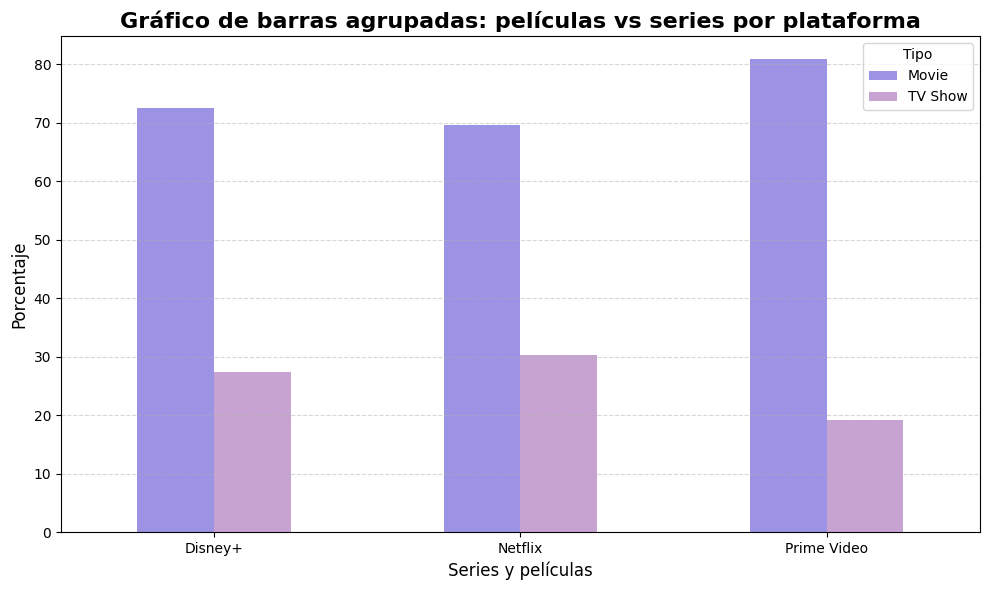

In [ ]:
#P15. Gráfico de barras agrupadas: películas vs series por plataforma

variable = df_universal.groupby('platform')['type'].value_counts(normalize=True)
resultado =variable * 100
pct_pel_ser = resultado.round(2)
resultado = pct_pel_ser.unstack()
print(resultado)

#Graficar
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (10,6)) #figura en blanco con tamaño 10,6
colores = ['#9c93e5', '#c7a3d2']
#que vamos a graficar
resultado.plot(
 kind='bar',
 ax=ax,
 rot=0,
 color = colores
 )

#personificar
ax.set_title('Gráfico de barras agrupadas: películas vs series por plataforma',
            fontsize=16,
            fontweight='bold')
ax.set_ylabel('Porcentaje', fontsize=12)
ax.set_xlabel('Series y películas', fontsize=12)


ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.legend(title='Tipo', labels=['Movie', 'TV Show'])

plt.tight_layout()
plt.show()

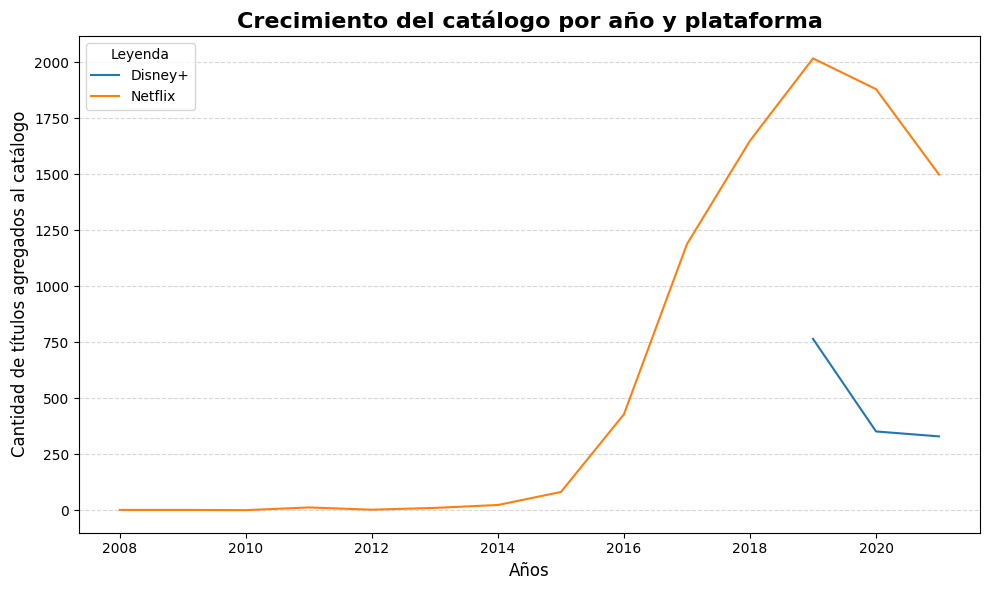

In [ ]:
#Línea temporal: crecimiento del catálogo por año y plataforma

df_agregados = df_universal[['year_added', 'platform']]

registrosnulos = df_agregados['year_added'].isnull().groupby(df_agregados['platform']).sum()
#registros totales
registrosporplataforma = df_universal.groupby('platform').size()
#porcentajes
resultado = registrosnulos * 100 / registrosporplataforma
#print(resultado.round(2))

df_net_dis = df_universal[df_universal['platform'] != 'Prime Video']

plataformaporaño = df_net_dis.groupby(['platform','year_added']).size()
plataformaporaño = plataformaporaño.unstack(0)

 #Graficar
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))

# ── QUÉ GRAFICAR ──
plataformaporaño.plot(kind='line', ax=ax)  # desde DataFrame

# ── PERSONALIZACIÓN ──
ax.set_title('Crecimiento del catálogo por año y plataforma', fontsize=16, fontweight='bold')
ax.set_xlabel('Años', fontsize=12)
ax.set_ylabel('Cantidad de títulos agregados al catálogo', fontsize=12)
ax.legend(title='Leyenda')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# ── CERRAR ──
plt.tight_layout()
plt.show()



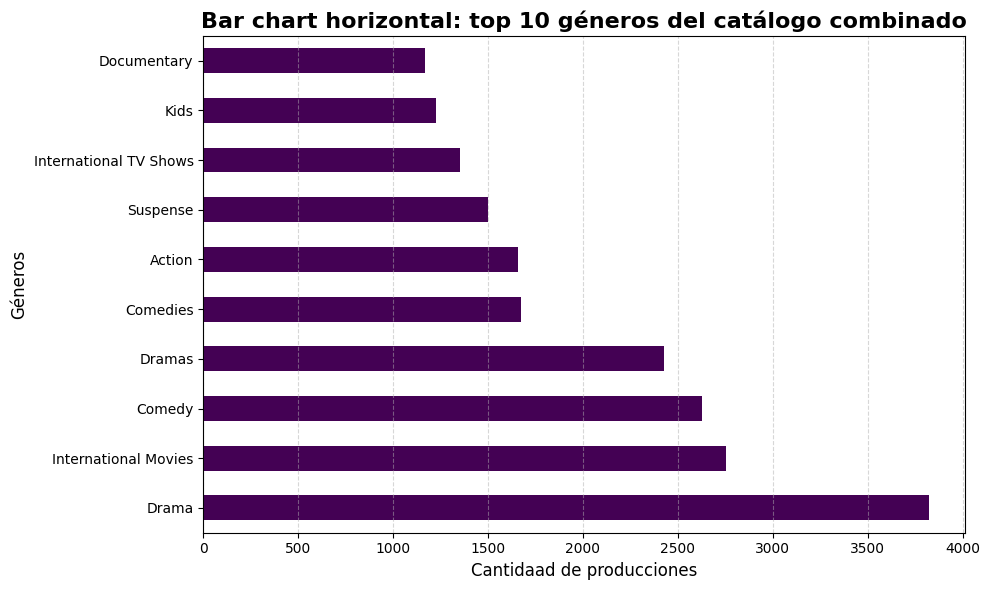

In [ ]:
#Bar chart horizontal: top 10 géneros del catálogo combinado

listed_in_partes = df_universal['listed_in'].str.split(',')
lista_de_generos = listed_in_partes.explode()
lista_de_generos_sin_espacios = lista_de_generos.str.strip()
lista_conteo_generos = lista_de_generos_sin_espacios.value_counts()
lista_top10_generos = lista_conteo_generos.head(10)
#print(lista_top10_generos)

#Graficar
#Graficar
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (10,6))

#que vamos a graficar
lista_top10_generos.plot(
 kind='barh',
 ax=ax,
 rot=0,
 colormap='viridis'
 )

#personificar
ax.set_title('Bar chart horizontal: top 10 géneros del catálogo combinado',
            fontsize=16,
            fontweight='bold')
ax.set_ylabel('Géneros', fontsize=12)
ax.set_xlabel('Cantidaad de producciones', fontsize=12)


ax.grid(axis='x', linestyle='--', alpha=0.5)

#ax.legend(title='Tipo', labels=['Movie', 'TV Show'])

plt.tight_layout()
plt.show()

In [ ]:
#Heatmap: cantidad de contenido agregado por mes y plataforma


platform    Disney+  Netflix
mes_nombre                  
Enero            61      738
Febrero          44      563
Marzo            24      742
Abril            86      764
Mayo             62      632
Junio            52      728
Julio            85      827
Agosto           50      755
Septiembre       59      770
Octubre          63      760
Noviembre       809      705
Diciembre        52      813


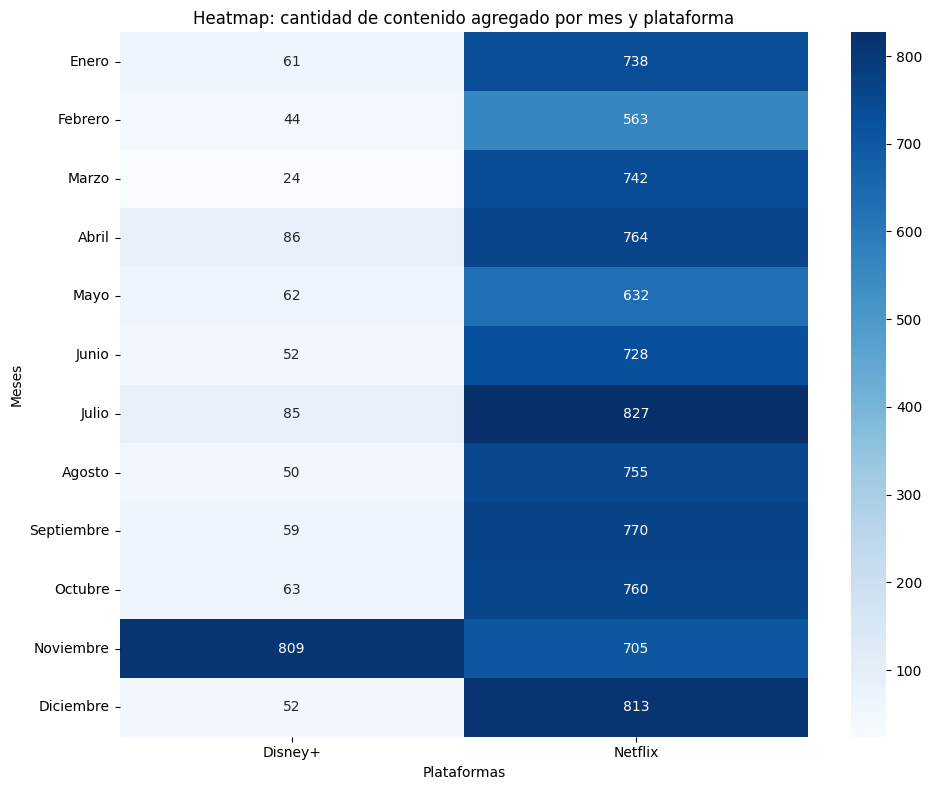

In [ ]:
#P18. Heatmap: cantidad de contenido agregado por mes y plataforma

#PORCENTAJE DE NULOS EN YEAR ADDED
#nuevo dataset con dos columnas
df_agregados_mes = df_universal[['month_added', 'platform']]
#df.groupby('columna_a_agrupar')['columna_a_analizar'].funcion()

#Verificamos los valores nulos de year added y los agrupamos por plataformas
registrosnulos_mes = df_agregados_mes['month_added'].isnull().groupby(df_agregados_mes['platform']).sum()
# Crear diccionario de mapeo
meses_dict = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}


#registros totales
registrosporplataforma = df_universal.groupby('platform').size()
#porcentajes
resultado = registrosnulos_mes * 100 / registrosporplataforma
#print(resultado.round(2))

df_net_dis = df_universal[df_universal['platform'] != 'Prime Video'].copy()

df_net_dis['mes_nombre'] = df_net_dis['month_added'].map(meses_dict)

df_net_dis.groupby(['platform', 'mes_nombre']).size()
# Usar reindex - guardar codigo en una variable
agrupacion = df_net_dis.groupby(['mes_nombre', 'platform']).size()
# Lista con meses en orden cronológico
meses_orden = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio','Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
# Reindexar para ordenar cronológicamente
agrupacion_ordenada = agrupacion.reindex(meses_orden, level='mes_nombre')
agrupacion_ordenada = agrupacion_ordenada.unstack()

print(agrupacion_ordenada)

#Graficar
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    agrupacion_ordenada,    # la tabla con meses como filas y plataformas como columnas
    annot= True,          # ¿mostrar números dentro de las celdas?
    fmt= 'g',            # formato de los números
    cmap= 'Blues',           # paleta de colores
    ax=ax
)

ax.set_title('Heatmap: cantidad de contenido agregado por mes y plataforma')
ax.set_xlabel('Plataformas')
ax.set_ylabel('Meses')

plt.tight_layout()
plt.show()

In [ ]:
#P19. ¿Existen títulos repetidos entre plataformas?

union_net_dis = pd.merge(df_netflix, df_disney, on='title', how='inner')
print(len(union_net_dis))
union_net_pri = pd.merge(df_netflix, df_prime, on='title', how='inner')
print(len(union_net_pri))
union_dis_pri = pd.merge(df_disney, df_prime, on='title', how='inner')
print(len(union_dis_pri))




43
389
16


In [ ]:
#¿Cuál plataforma tiene ratings más variados?
df_universal['rating'].nunique()

df_universal.groupby('platform')['rating'].nunique()

variable = df_universal.groupby('platform')['rating'].value_counts()

print(variable)

platform     rating  
Disney+      TV-G         318
             TV-PG        301
             G            253
             PG           236
             TV-Y7        131
             TV-14         79
             PG-13         66
             TV-Y          50
             TV-Y7-FV      13
Netflix      TV-MA       3207
             TV-14       2160
             TV-PG        863
             R            799
             PG-13        490
             TV-Y7        334
             TV-Y         307
             PG           287
             TV-G         220
             NR            80
             G             41
             TV-Y7-FV       6
             NC-17          3
             UR             3
             66 min         1
             74 min         1
             84 min         1
Prime Video  13+         2117
             16+         1547
             ALL         1268
             18+         1243
             R           1010
             PG-13        393
             7+   

In [ ]:
df_universal.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform,year_added,month_added,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Netflix,2021.0,9.0,90.0,min
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Netflix,2021.0,9.0,2.0,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Netflix,2021.0,9.0,1.0,Season
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Netflix,2021.0,9.0,1.0,Season
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Netflix,2021.0,9.0,2.0,Seasons
